# Phase 4 — LSTM seq2seq + Bahdanau attention

Same encoder/decoder as Phase 3, plus a **Bahdanau additive attention** module that lets the decoder query the full sequence of encoder hidden states at every output step. All other hyperparameters held constant for an honest comparison with Phase 3.

**Spec:** ~10.5M params - cross-entropy (pad ignored) - Adam lr=1e-3 - ReduceLROnPlateau - grad clip 1.0 - mixed precision - greedy + beam=4 inference - attention weights captured for heatmaps.

**Targets:** 3 epochs, early stopping on val GLEU. Estimated Kaggle T4/P100 runtime: 6-8 h.

In [1]:
!pip install tokenizers nltk -q
import nltk; nltk.download("punkt", quiet=True)

import os, math, time, random, json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from tokenizers import ByteLevelBPETokenizer
from nltk.translate.gleu_score import corpus_gleu

SEED = 42
random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "| Torch:", torch.__version__)

Device: cuda | Torch: 2.10.0+cu128


In [ ]:
assert torch.cuda.is_available(), "No GPU. Settings -> Accelerator -> GPU T4 x2."
print("Device :", torch.cuda.get_device_name(0))
print("VRAM   :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
_x = torch.randn(8, 8, device="cuda") @ torch.randn(8, 8, device="cuda")
print("CUDA kernel test OK, sum =", round(_x.sum().item(), 3))

Device : Tesla T4
VRAM   : 15.6 GB
CUDA kernel test OK, sum = -11.377


## 1. Paths and config

Single `CFG` dict - same as Phase 3 except `use_attention=True`, new `attn_dim`, fresh `OUT_DIR`. `RUN_MODE` toggles smoke / dev / final.

In [ ]:
DATA_DIR  = "/kaggle/input/datasets/ibrahimhany202200518/gec-c4-5m-splits/data"
TOKEN_DIR = "/kaggle/input/datasets/ibrahimhany202200518/gec-bpe-tokenizer/tokenizer"
PH3_DIR   = "/kaggle/input/datasets/ibrahimhany202200518/gec-phase3-lstm-noattn/lstm_noattn"  # Phase 3 results

CFG = {
    "vocab_size":    16000,
    "emb_dim":       256,
    "enc_hidden":    256,
    "dec_hidden":    512,
    "attn_dim":      256,
    "max_len":       64,
    "batch_size":    64,
    "lr":            1e-3,
    "weight_decay":  1e-5,
    "clip":          1.0,
    "epochs":        3,
    "tf_start":      1.0,
    "tf_end":        0.5,
    "log_every":     200,
    "ckpt_every":    2000,
    "max_train":     850_000,
    "max_val":       50_000,
    "max_test":      100_000,
    "max_val_eval":  5_000,
    "use_attention": True,
}

PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3

# RUN_MODE overrides for quick experiments; "final" = full 1M run
RUN_MODE = "final"  # "smoke" | "dev" | "final"
CFG["max_train"]   = {"smoke": 10_000, "dev": 100_000, "final": 850_000}[RUN_MODE]
CFG["max_val"]     = {"smoke":  2_000, "dev":  10_000, "final":  50_000}[RUN_MODE]
CFG["max_test"]    = {"smoke":  2_000, "dev":  10_000, "final": 100_000}[RUN_MODE]
CFG["epochs"]      = {"smoke": 1,      "dev": 2,       "final": 3}[RUN_MODE]
OUT_DIR = f"/kaggle/working/lstm_bahdanau_{RUN_MODE}"
os.makedirs(OUT_DIR, exist_ok=True)
print("Mode:", RUN_MODE, "| OUT_DIR:", OUT_DIR)
print(f"Budget: train={CFG['max_train']:,}  val={CFG['max_val']:,}  "
      f"test={CFG['max_test']:,}  total={CFG['max_train']+CFG['max_val']+CFG['max_test']:,}")

Mode: final | OUT_DIR: /kaggle/working/lstm_bahdanau_final
Budget: train=850,000  val=50,000  test=100,000  total=1,000,000


## 2. Load tokenizer

Reload the 16k ByteLevel BPE tokenizer from Phase 1. Asserts pin special-token IDs.

In [4]:
tokenizer = ByteLevelBPETokenizer(
    f"{TOKEN_DIR}/vocab.json",
    f"{TOKEN_DIR}/merges.txt",
)
tokenizer.add_special_tokens(["<pad>", "<unk>", "<s>", "</s>"])
assert tokenizer.token_to_id("<pad>") == PAD_ID
assert tokenizer.token_to_id("<s>")   == BOS_ID
assert tokenizer.token_to_id("</s>")  == EOS_ID
print("Vocab size:", tokenizer.get_vocab_size())

Vocab size: 16000


## 3. Dataset and collate

`GECDataset` lazy-loads `(corrupted, clean)` pairs and tokenizes on the fly. Encoder input has no special tokens; decoder target wrapped as `[<s>, ..., </s>]`. `collate_fn` does dynamic padding per batch.

In [5]:
class GECDataset(Dataset):
    def __init__(self, path, tokenizer, max_len=64, limit=None):
        self.pairs = []
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.rstrip("\n").split("\t")
                if len(parts) != 2:
                    continue
                self.pairs.append((parts[0], parts[1]))
                if limit is not None and len(self.pairs) >= limit:
                    break
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        src, tgt = self.pairs[i]
        src_ids = self.tok.encode(src).ids[: self.max_len]
        tgt_ids = self.tok.encode(tgt).ids[: self.max_len - 2]
        tgt_ids = [BOS_ID] + tgt_ids + [EOS_ID]
        if len(src_ids) == 0:
            src_ids = [UNK_ID]
        return torch.tensor(src_ids, dtype=torch.long), \
               torch.tensor(tgt_ids, dtype=torch.long)


def collate(batch):
    srcs, tgts = zip(*batch)
    src_lens = torch.tensor([len(s) for s in srcs], dtype=torch.long)
    tgt_lens = torch.tensor([len(t) for t in tgts], dtype=torch.long)
    src_pad = nn.utils.rnn.pad_sequence(srcs, batch_first=True, padding_value=PAD_ID)
    tgt_pad = nn.utils.rnn.pad_sequence(tgts, batch_first=True, padding_value=PAD_ID)
    return src_pad, src_lens, tgt_pad, tgt_lens


train_ds = GECDataset(f"{DATA_DIR}/train.tsv", tokenizer, CFG["max_len"], CFG["max_train"])
val_ds   = GECDataset(f"{DATA_DIR}/val.tsv",   tokenizer, CFG["max_len"], CFG["max_val"])
test_ds  = GECDataset(f"{DATA_DIR}/test.tsv",  tokenizer, CFG["max_len"], CFG["max_test"])

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=2, pin_memory=True, collate_fn=collate)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=2, pin_memory=True, collate_fn=collate)
test_loader  = DataLoader(test_ds,  batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=2, pin_memory=True, collate_fn=collate)

print(f"Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}")
print(f"Total: {len(train_ds)+len(val_ds)+len(test_ds):,}")
print("steps/epoch:", len(train_loader), "| total steps:", len(train_loader) * CFG["epochs"])

Train: 850,000  Val: 50,000  Test: 85,000
Total: 985,000
steps/epoch: 13282 | total steps: 39846


## 4. Model - Encoder + BahdanauAttention + AttnDecoder

**Encoder** unchanged from Phase 3, but we keep the full sequence of bidirectional outputs `(B, T_src, 512)` for attention to query.

**BahdanauAttention** - additive score `v^T tanh(W_s s_t + W_h h_i)`, masks PAD positions, softmax over source, returns context + weights.

**AttnDecoder** runs one step at a time: input is `[embedding(prev_tok) ; context]`, output projection takes `[hidden ; context]`.

**Seq2SeqAttn** wrapper returns `(logits, attn_weights)` for heatmaps.

In [6]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_hidden, dec_hidden, pad_id=PAD_ID):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(emb_dim, enc_hidden, batch_first=True, bidirectional=True)
        self.h_proj = nn.Linear(enc_hidden * 2, dec_hidden)
        self.c_proj = nn.Linear(enc_hidden * 2, dec_hidden)

    def forward(self, src, src_lens):
        emb = self.embedding(src)
        packed = nn.utils.rnn.pack_padded_sequence(emb, src_lens.cpu(),
                                                   batch_first=True, enforce_sorted=False)
        outputs, (h, c) = self.lstm(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(outputs, batch_first=True)
        h_cat = torch.cat([h[0], h[1]], dim=-1)
        c_cat = torch.cat([c[0], c[1]], dim=-1)
        h0 = torch.tanh(self.h_proj(h_cat)).unsqueeze(0)
        c0 = torch.tanh(self.c_proj(c_cat)).unsqueeze(0)
        return outputs, (h0, c0)


class BahdanauAttention(nn.Module):
    """Additive attention: score = v^T tanh(W_s s_t + W_h h_i)."""
    def __init__(self, enc_dim, dec_dim, attn_dim):
        super().__init__()
        self.W_s = nn.Linear(dec_dim, attn_dim, bias=False)
        self.W_h = nn.Linear(enc_dim, attn_dim, bias=False)
        self.v   = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, s_t, enc_out, src_mask):
        # s_t: (B, dec_dim) | enc_out: (B, T_src, enc_dim) | src_mask: (B, T_src) True at PAD
        s_proj = self.W_s(s_t).unsqueeze(1)                       # (B, 1, attn_dim)
        h_proj = self.W_h(enc_out)                                # (B, T_src, attn_dim)
        scores = self.v(torch.tanh(s_proj + h_proj)).squeeze(-1)  # (B, T_src)
        scores = scores.masked_fill(src_mask, float("-inf"))
        alpha  = F.softmax(scores, dim=-1)                        # (B, T_src)
        ctx    = torch.bmm(alpha.unsqueeze(1), enc_out).squeeze(1)  # (B, enc_dim)
        return ctx, alpha


class AttnDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, dec_hidden, enc_dim, attn_dim, pad_id=PAD_ID):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.attn = BahdanauAttention(enc_dim, dec_hidden, attn_dim)
        self.lstm = nn.LSTM(emb_dim + enc_dim, dec_hidden, batch_first=True)
        self.out  = nn.Linear(dec_hidden + enc_dim, vocab_size)

    def step(self, prev_tok, state, enc_out, src_mask):
        emb = self.embedding(prev_tok).unsqueeze(1)               # (B, 1, emb_dim)
        s_t = state[0].squeeze(0)                                 # (B, dec_dim)
        ctx, alpha = self.attn(s_t, enc_out, src_mask)            # (B, enc_dim), (B, T_src)
        rnn_in = torch.cat([emb, ctx.unsqueeze(1)], dim=-1)      # (B, 1, emb+enc)
        out, state = self.lstm(rnn_in, state)                     # out: (B, 1, dec_dim)
        logits = self.out(torch.cat([out.squeeze(1), ctx], dim=-1))  # (B, vocab)
        return logits, state, alpha


class Seq2SeqAttn(nn.Module):
    def __init__(self, encoder, decoder, pad_id=PAD_ID):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_id  = pad_id

    def make_src_mask(self, src):
        return src == self.pad_id

    def forward(self, src, src_lens, tgt_in):
        enc_out, state = self.encoder(src, src_lens)
        src_mask = self.make_src_mask(src)
        B, T_tgt = tgt_in.size()
        all_logits, all_alpha = [], []
        for t in range(T_tgt):
            logits, state, alpha = self.decoder.step(tgt_in[:, t], state, enc_out, src_mask)
            all_logits.append(logits)
            all_alpha.append(alpha)
        return torch.stack(all_logits, dim=1), torch.stack(all_alpha, dim=1)

    @torch.no_grad()
    def greedy_decode(self, src, src_lens, max_len=64, return_attn=False):
        self.eval()
        B = src.size(0)
        enc_out, state = self.encoder(src, src_lens)
        src_mask = self.make_src_mask(src)
        ys = torch.full((B,), BOS_ID, dtype=torch.long, device=src.device)
        finished = torch.zeros(B, dtype=torch.bool, device=src.device)
        outputs, attn_steps = [], []
        for _ in range(max_len):
            logits, state, alpha = self.decoder.step(ys, state, enc_out, src_mask)
            next_tok = logits.argmax(-1)
            next_tok = torch.where(finished, torch.full_like(next_tok, PAD_ID), next_tok)
            outputs.append(next_tok); attn_steps.append(alpha)
            ys = next_tok
            finished = finished | (next_tok == EOS_ID)
            if finished.all():
                break
        out_ids = torch.stack(outputs, dim=1)
        if return_attn:
            return out_ids, torch.stack(attn_steps, dim=1)
        return out_ids


encoder = Encoder(CFG["vocab_size"], CFG["emb_dim"], CFG["enc_hidden"], CFG["dec_hidden"])
decoder = AttnDecoder(CFG["vocab_size"], CFG["emb_dim"], CFG["dec_hidden"],
                      enc_dim=CFG["enc_hidden"] * 2, attn_dim=CFG["attn_dim"])
model   = Seq2SeqAttn(encoder, decoder).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {n_params/1e6:.2f}M")

Trainable params: 29.06M


## 5. Loss, optimizer, scheduler

Cross-entropy (pad ignored), Adam lr=1e-3, ReduceLROnPlateau on val loss, AMP GradScaler. Identical to Phase 3.

In [7]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
optimizer = torch.optim.Adam(model.parameters(),
                             lr=CFG["lr"], weight_decay=CFG["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2)
scaler = GradScaler()

/tmp/ipykernel_23/3333420250.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


## 5b. Sanity check - attention mask

After a forward pass, attention rows should sum to ~1 and put ~0 weight on PAD positions. Run this once before launching the final training; if PAD weight is non-zero, the mask is broken.

In [8]:
_src, _src_lens, _tgt, _ = next(iter(val_loader))
_src = _src.to(DEVICE); _src_lens = _src_lens.to(DEVICE)
with torch.no_grad():
    _, _attn = model(_src, _src_lens, _tgt[:, :-1].to(DEVICE))
print("attn shape:", tuple(_attn.shape), "(B, T_tgt, T_src)")
print("row sum (should be ~1.0):", round(_attn[0, 0].sum().item(), 4))
_pad_positions = (_src[0] == PAD_ID)
if _pad_positions.any():
    print("max weight on PAD (should be ~0):",
          round(_attn[0, 0][_pad_positions].max().item(), 6))
else:
    print("no PAD in this sample")
del _src, _src_lens, _tgt, _attn

attn shape: (64, 63, 64) (B, T_tgt, T_src)
row sum (should be ~1.0): 1.0
max weight on PAD (should be ~0): 0.0


## 6. Validation - greedy decode + GLEU

Per-token teacher-forced loss for the LR scheduler; corpus GLEU from greedy decoding for early stopping. Forward returns `(logits, attention)`; attention discarded here.

In [9]:
def ids_to_text(ids):
    out = []
    for i in ids:
        i = int(i)
        if i in (BOS_ID, PAD_ID):
            continue
        if i == EOS_ID:
            break
        out.append(i)
    return tokenizer.decode(out)


@torch.no_grad()
def evaluate_gleu(model, loader, max_batches=None):
    model.eval()
    refs, hyps = [], []
    total_loss, total_tokens = 0.0, 0
    for bi, (src, src_lens, tgt, tgt_lens) in enumerate(loader):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        src_lens = src_lens.to(DEVICE)
        tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]
        with autocast():
            logits, _ = model(src, src_lens, tgt_in)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
        n_tok = (tgt_out != PAD_ID).sum().item()
        total_loss   += loss.item() * n_tok
        total_tokens += n_tok
        gen = model.greedy_decode(src, src_lens, max_len=CFG["max_len"])
        for g, t in zip(gen.cpu().tolist(), tgt.cpu().tolist()):
            hyps.append(ids_to_text(g).split())
            refs.append([ids_to_text(t).split()])
        if max_batches is not None and bi + 1 >= max_batches:
            break
    avg_loss = total_loss / max(total_tokens, 1)
    gleu = corpus_gleu(refs, hyps)
    return avg_loss, gleu

## 7. Training loop

Forward -> CE loss (pad ignored) -> scaled backward -> unscale + clip -> optimizer step. `last.pt` checkpointed every `ckpt_every` steps; `best.pt` saved only when val GLEU improves.

In [10]:
def save_ckpt(path, model, optimizer, step, epoch, best_gleu):
    torch.save({
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "step": step, "epoch": epoch, "best_gleu": best_gleu, "cfg": CFG,
    }, path)


def train_one_epoch(model, loader, epoch, global_step, best_gleu, tf_ratio):
    model.train()
    running_loss, running_tokens = 0.0, 0
    t0 = time.time()
    for src, src_lens, tgt, tgt_lens in loader:
        src, tgt = src.to(DEVICE, non_blocking=True), tgt.to(DEVICE, non_blocking=True)
        src_lens = src_lens.to(DEVICE)
        tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]

        optimizer.zero_grad(set_to_none=True)
        with autocast():
            logits, _ = model(src, src_lens, tgt_in)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["clip"])
        scaler.step(optimizer); scaler.update()

        n_tok = (tgt_out != PAD_ID).sum().item()
        running_loss   += loss.item() * n_tok
        running_tokens += n_tok
        global_step += 1

        if global_step % CFG["log_every"] == 0:
            cur = running_loss / max(running_tokens, 1)
            lr = optimizer.param_groups[0]["lr"]
            dt = time.time() - t0
            print(f"  step {global_step:>7} | loss {cur:.4f} | ppl {math.exp(cur):.1f} "
                  f"| lr {lr:.2e} | tf {tf_ratio:.2f} | {dt:.0f}s")
            running_loss, running_tokens, t0 = 0.0, 0, time.time()

        if global_step % CFG["ckpt_every"] == 0:
            save_ckpt(f"{OUT_DIR}/last.pt", model, optimizer, global_step, epoch, best_gleu)

    return global_step

In [11]:
best_gleu = -1.0
global_step = 0

# cap greedy-decode eval to max_val_eval samples for speed (full val_ds used for loss)
_eval_batches = CFG["max_val_eval"] // CFG["batch_size"]

for epoch in range(1, CFG["epochs"] + 1):
    frac = (epoch - 1) / max(CFG["epochs"] - 1, 1)
    tf_ratio = CFG["tf_start"] + frac * (CFG["tf_end"] - CFG["tf_start"])
    print(f"\n=== Epoch {epoch}/{CFG['epochs']} (tf={tf_ratio:.2f}) ===")
    global_step = train_one_epoch(model, train_loader, epoch, global_step, best_gleu, tf_ratio)

    print(f"Validating (greedy on first {CFG['max_val_eval']:,} val samples)...")
    val_loss, val_gleu = evaluate_gleu(model, val_loader, max_batches=_eval_batches)
    print(f"epoch {epoch}: val_loss={val_loss:.4f}  val_gleu={val_gleu:.4f}")
    scheduler.step(val_loss)

    save_ckpt(f"{OUT_DIR}/last.pt", model, optimizer, global_step, epoch, best_gleu)
    if val_gleu > best_gleu:
        best_gleu = val_gleu
        save_ckpt(f"{OUT_DIR}/best.pt", model, optimizer, global_step, epoch, best_gleu)
        print(f"  -> new best, saved to {OUT_DIR}/best.pt")


=== Epoch 1/3 (tf=1.00) ===


/tmp/ipykernel_23/17881824.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  step     200 | loss 7.2018 | ppl 1341.9 | lr 1.00e-03 | tf 1.00 | 45s
  step     400 | loss 5.8462 | ppl 345.9 | lr 1.00e-03 | tf 1.00 | 45s
  step     600 | loss 4.3670 | ppl 78.8 | lr 1.00e-03 | tf 1.00 | 44s
  step     800 | loss 3.4640 | ppl 31.9 | lr 1.00e-03 | tf 1.00 | 43s
  step    1000 | loss 2.9846 | ppl 19.8 | lr 1.00e-03 | tf 1.00 | 44s
  step    1200 | loss 2.7031 | ppl 14.9 | lr 1.00e-03 | tf 1.00 | 44s
  step    1400 | loss 2.5117 | ppl 12.3 | lr 1.00e-03 | tf 1.00 | 43s
  step    1600 | loss 2.3729 | ppl 10.7 | lr 1.00e-03 | tf 1.00 | 44s
  step    1800 | loss 2.2886 | ppl 9.9 | lr 1.00e-03 | tf 1.00 | 43s
  step    2000 | loss 2.1874 | ppl 8.9 | lr 1.00e-03 | tf 1.00 | 43s
  step    2200 | loss 2.0981 | ppl 8.2 | lr 1.00e-03 | tf 1.00 | 44s
  step    2400 | loss 2.0605 | ppl 7.8 | lr 1.00e-03 | tf 1.00 | 44s
  step    2600 | loss 2.0021 | ppl 7.4 | lr 1.00e-03 | tf 1.00 | 44s
  step    2800 | loss 1.9999 | ppl 7.4 | lr 1.00e-03 | tf 1.00 | 44s
  step    3000 | loss 1

/tmp/ipykernel_23/441058597.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


epoch 1: val_loss=1.3978  val_gleu=0.5832
  -> new best, saved to /kaggle/working/lstm_bahdanau_final/best.pt

=== Epoch 2/3 (tf=0.75) ===
  step   13400 | loss 1.3014 | ppl 3.7 | lr 1.00e-03 | tf 0.75 | 26s
  step   13600 | loss 1.3261 | ppl 3.8 | lr 1.00e-03 | tf 0.75 | 43s
  step   13800 | loss 1.3135 | ppl 3.7 | lr 1.00e-03 | tf 0.75 | 44s
  step   14000 | loss 1.3229 | ppl 3.8 | lr 1.00e-03 | tf 0.75 | 44s
  step   14200 | loss 1.2966 | ppl 3.7 | lr 1.00e-03 | tf 0.75 | 44s
  step   14400 | loss 1.3163 | ppl 3.7 | lr 1.00e-03 | tf 0.75 | 43s
  step   14600 | loss 1.3124 | ppl 3.7 | lr 1.00e-03 | tf 0.75 | 44s
  step   14800 | loss 1.3169 | ppl 3.7 | lr 1.00e-03 | tf 0.75 | 43s
  step   15000 | loss 1.3077 | ppl 3.7 | lr 1.00e-03 | tf 0.75 | 43s
  step   15200 | loss 1.3107 | ppl 3.7 | lr 1.00e-03 | tf 0.75 | 43s
  step   15400 | loss 1.3205 | ppl 3.7 | lr 1.00e-03 | tf 0.75 | 43s
  step   15600 | loss 1.3267 | ppl 3.8 | lr 1.00e-03 | tf 0.75 | 43s
  step   15800 | loss 1.3241 | pp

## 8. Test set - greedy decoding

Load `best.pt`, decode greedily over the full test set, save `(src, pred, ref)` TSV.

In [12]:
ckpt = torch.load(f"{OUT_DIR}/best.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model"])
print("Loaded best from epoch", ckpt["epoch"], "step", ckpt["step"])

preds_greedy, refs_text, srcs_text = [], [], []
model.eval()
with torch.no_grad():
    for src, src_lens, tgt, tgt_lens in test_loader:
        src = src.to(DEVICE); src_lens = src_lens.to(DEVICE)
        gen = model.greedy_decode(src, src_lens, max_len=CFG["max_len"])
        for s, g, t in zip(src.cpu().tolist(), gen.cpu().tolist(), tgt.cpu().tolist()):
            srcs_text.append(ids_to_text(s))
            preds_greedy.append(ids_to_text(g))
            refs_text.append(ids_to_text(t))

with open(f"{OUT_DIR}/test_predictions_greedy.tsv", "w", encoding="utf-8") as f:
    for s, p, r in zip(srcs_text, preds_greedy, refs_text):
        f.write(f"{s}\t{p}\t{r}\n")
print("Saved:", f"{OUT_DIR}/test_predictions_greedy.tsv", "| rows:", len(srcs_text))

Loaded best from epoch 3 step 39846
Saved: /kaggle/working/lstm_bahdanau_final/test_predictions_greedy.tsv | rows: 85000


## 8b. Test set - beam=4

Length-normalised beam search (alpha=0.7). Slower than Phase 3 because attention is recomputed each step. If too slow, drop `beam` to 3.

In [13]:
@torch.no_grad()
def beam_decode_one(model, src_ids, src_len, beam=4, max_len=64, alpha=0.7):
    model.eval()
    src = src_ids.unsqueeze(0).to(DEVICE)
    src_lens = torch.tensor([src_len], device=DEVICE)
    enc_out, state = model.encoder(src, src_lens)
    src_mask = model.make_src_mask(src)
    h, c = state
    beams = [(0.0, [BOS_ID], h, c, False)]
    for _ in range(max_len):
        new_beams = []
        for score, toks, hh, cc, fin in beams:
            if fin:
                new_beams.append((score, toks, hh, cc, fin)); continue
            last = torch.tensor([toks[-1]], device=DEVICE)
            logits, (hh2, cc2), _ = model.decoder.step(last, (hh, cc), enc_out, src_mask)
            log_probs = F.log_softmax(logits, dim=-1).squeeze(0)
            top_lp, top_ix = log_probs.topk(beam)
            for lp, ix in zip(top_lp.tolist(), top_ix.tolist()):
                new_beams.append((score + lp, toks + [ix], hh2, cc2, ix == EOS_ID))
        new_beams.sort(key=lambda b: b[0] / (len(b[1]) ** alpha), reverse=True)
        beams = new_beams[:beam]
        if all(b[4] for b in beams):
            break
    return beams[0][1]


preds_beam = []
t0 = time.time()
for i, (src, tgt) in enumerate(test_ds):
    out_ids = beam_decode_one(model, src, len(src), beam=4, max_len=CFG["max_len"])
    preds_beam.append(ids_to_text(out_ids))
    if (i + 1) % 5000 == 0:
        print(f"  beam decoded {i+1}/{len(test_ds)}  ({time.time()-t0:.0f}s)")

with open(f"{OUT_DIR}/test_predictions_beam4.tsv", "w", encoding="utf-8") as f:
    for s, p, r in zip(srcs_text, preds_beam, refs_text):
        f.write(f"{s}\t{p}\t{r}\n")
print("Saved beam=4 predictions:", len(preds_beam))

  beam decoded 5000/85000  (600s)
  beam decoded 10000/85000  (1197s)
  beam decoded 15000/85000  (1792s)
  beam decoded 20000/85000  (2396s)
  beam decoded 25000/85000  (2993s)
  beam decoded 30000/85000  (3588s)
  beam decoded 35000/85000  (4188s)
  beam decoded 40000/85000  (4790s)
  beam decoded 45000/85000  (5391s)
  beam decoded 50000/85000  (5985s)
  beam decoded 55000/85000  (6593s)
  beam decoded 60000/85000  (7193s)
  beam decoded 65000/85000  (7798s)
  beam decoded 70000/85000  (8401s)
  beam decoded 75000/85000  (9000s)
  beam decoded 80000/85000  (9595s)
  beam decoded 85000/85000  (10190s)
Saved beam=4 predictions: 85000


## 9. Metrics

Exact-match, GLEU, token-level Precision/Recall/F0.5, length-bucketed exact-match.

In [14]:
from collections import Counter


def exact_match(preds, refs):
    return sum(p.strip() == r.strip() for p, r in zip(preds, refs)) / len(preds)


def token_prf(preds, refs, beta=0.5):
    tp = fp = fn = 0
    for p, r in zip(preds, refs):
        pc, rc = Counter(p.split()), Counter(r.split())
        for tok, n in pc.items():
            tp += min(n, rc.get(tok, 0))
            fp += max(0, n - rc.get(tok, 0))
        for tok, n in rc.items():
            fn += max(0, n - pc.get(tok, 0))
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f = (1 + beta**2) * prec * rec / (beta**2 * prec + rec + 1e-9)
    return prec, rec, f


def length_bucketed_em(srcs, preds, refs):
    buckets = {"short(<=10)": [], "med(11-20)": [], "long(>20)": []}
    for s, p, r in zip(srcs, preds, refs):
        n = len(r.split())
        key = "short(<=10)" if n <= 10 else "med(11-20)" if n <= 20 else "long(>20)"
        buckets[key].append(p.strip() == r.strip())
    return {k: (sum(v)/len(v) if v else 0.0, len(v)) for k, v in buckets.items()}


for name, preds in [("greedy", preds_greedy), ("beam=4", preds_beam)]:
    em = exact_match(preds, refs_text)
    gleu = corpus_gleu([[r.split()] for r in refs_text], [p.split() for p in preds])
    p, r, f05 = token_prf(preds, refs_text, beta=0.5)
    buckets = length_bucketed_em(srcs_text, preds, refs_text)
    print(f"\n--- {name} ---")
    print(f"Exact-match : {em:.4f}")
    print(f"GLEU        : {gleu:.4f}")
    print(f"Precision   : {p:.4f}")
    print(f"Recall      : {r:.4f}")
    print(f"F0.5        : {f05:.4f}")
    for k, (acc, n) in buckets.items():
        print(f"  EM {k:>14}  {acc:.4f}  (n={n})")


--- greedy ---
Exact-match : 0.0239
GLEU        : 0.5993
Precision   : 0.7956
Recall      : 0.7930
F0.5        : 0.7951
  EM    short(<=10)  0.0551  (n=21199)
  EM     med(11-20)  0.0222  (n=28830)
  EM      long(>20)  0.0063  (n=34971)

--- beam=4 ---
Exact-match : 0.0264
GLEU        : 0.6184
Precision   : 0.8094
Recall      : 0.8065
F0.5        : 0.8088
  EM    short(<=10)  0.0592  (n=21199)
  EM     med(11-20)  0.0255  (n=28830)
  EM      long(>20)  0.0074  (n=34971)


## 10. Side-by-side comparison with Phase 3

Load Phase 3's `summary.json` and predictions, recompute identical-method metrics, print the comparison table.

In [15]:
ph3 = json.load(open(f"{PH3_DIR}/summary.json"))

ph3_preds, ph3_refs, ph3_srcs = [], [], []
with open(f"{PH3_DIR}/test_predictions_greedy.tsv", "r", encoding="utf-8") as f:
    for line in f:
        parts = line.rstrip("\n").split("\t")
        if len(parts) != 3:
            continue
        s, p, r = parts
        ph3_srcs.append(s); ph3_preds.append(p); ph3_refs.append(r)


def all_metrics(preds, refs, srcs):
    em = exact_match(preds, refs)
    gleu = corpus_gleu([[r.split()] for r in refs], [p.split() for p in preds])
    p, r, f05 = token_prf(preds, refs, beta=0.5)
    buckets = length_bucketed_em(srcs, preds, refs)
    return {"EM": em, "GLEU": gleu, "P": p, "R": r, "F05": f05, "buckets": buckets}


m3 = all_metrics(ph3_preds, ph3_refs, ph3_srcs)
m4 = all_metrics(preds_greedy, refs_text, srcs_text)

print(f"{'Metric':<10} {'Phase 3':>12} {'Phase 4':>12} {'Delta':>12}")
for k in ["EM", "GLEU", "P", "R", "F05"]:
    print(f"{k:<10} {m3[k]:>12.4f} {m4[k]:>12.4f} {m4[k]-m3[k]:>+12.4f}")

print("\nLength-bucketed exact-match:")
for bk in m3["buckets"]:
    a3, n3 = m3["buckets"][bk]
    a4, n4 = m4["buckets"][bk]
    print(f"  {bk:<14}  P3={a3:.4f}  P4={a4:.4f}  Delta={a4-a3:+.4f}  (n={n4})")

Metric          Phase 3      Phase 4        Delta
EM               0.0080       0.0239      +0.0158
GLEU             0.2128       0.5993      +0.3865
P                0.4655       0.7956      +0.3301
R                0.4629       0.7930      +0.3301
F05              0.4650       0.7951      +0.3301

Length-bucketed exact-match:
  short(<=10)     P3=0.0265  P4=0.0551  Delta=+0.0287  (n=21199)
  med(11-20)      P3=0.0042  P4=0.0222  Delta=+0.0180  (n=28830)
  long(>20)       P3=0.0000  P4=0.0063  Delta=+0.0063  (n=34971)


## 10b. Length-bucketed comparison plot

The key figure for the report: attention should lift long-sentence accuracy more than short.

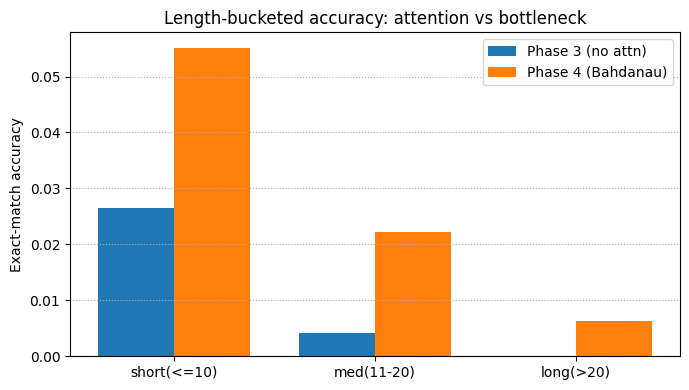

In [16]:
import matplotlib.pyplot as plt
import numpy as np

bks = list(m3["buckets"].keys())
v3 = [m3["buckets"][k][0] for k in bks]
v4 = [m4["buckets"][k][0] for k in bks]
x = np.arange(len(bks)); w = 0.38

plt.figure(figsize=(7, 4))
plt.bar(x - w/2, v3, w, label="Phase 3 (no attn)")
plt.bar(x + w/2, v4, w, label="Phase 4 (Bahdanau)")
plt.xticks(x, bks)
plt.ylabel("Exact-match accuracy")
plt.title("Length-bucketed accuracy: attention vs bottleneck")
plt.legend(); plt.grid(axis="y", linestyle=":")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/length_bucketed_compare.png", dpi=150)
plt.show()

## 11. Attention heatmaps

For hand-picked test sentences, plot the attention matrix (x = source tokens, y = generated tokens). Expect roughly diagonal alignment with off-diagonal spikes where the model fixes an error. Edit `PICKS` after looking at outputs.

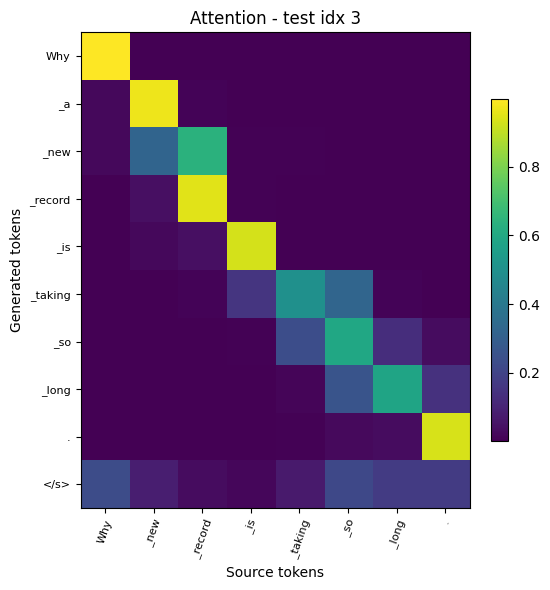

[3] SRC : Why new record is taking so long.
     PRED: Why a new record is taking so long.
     REF : Why the new record is taking so long.



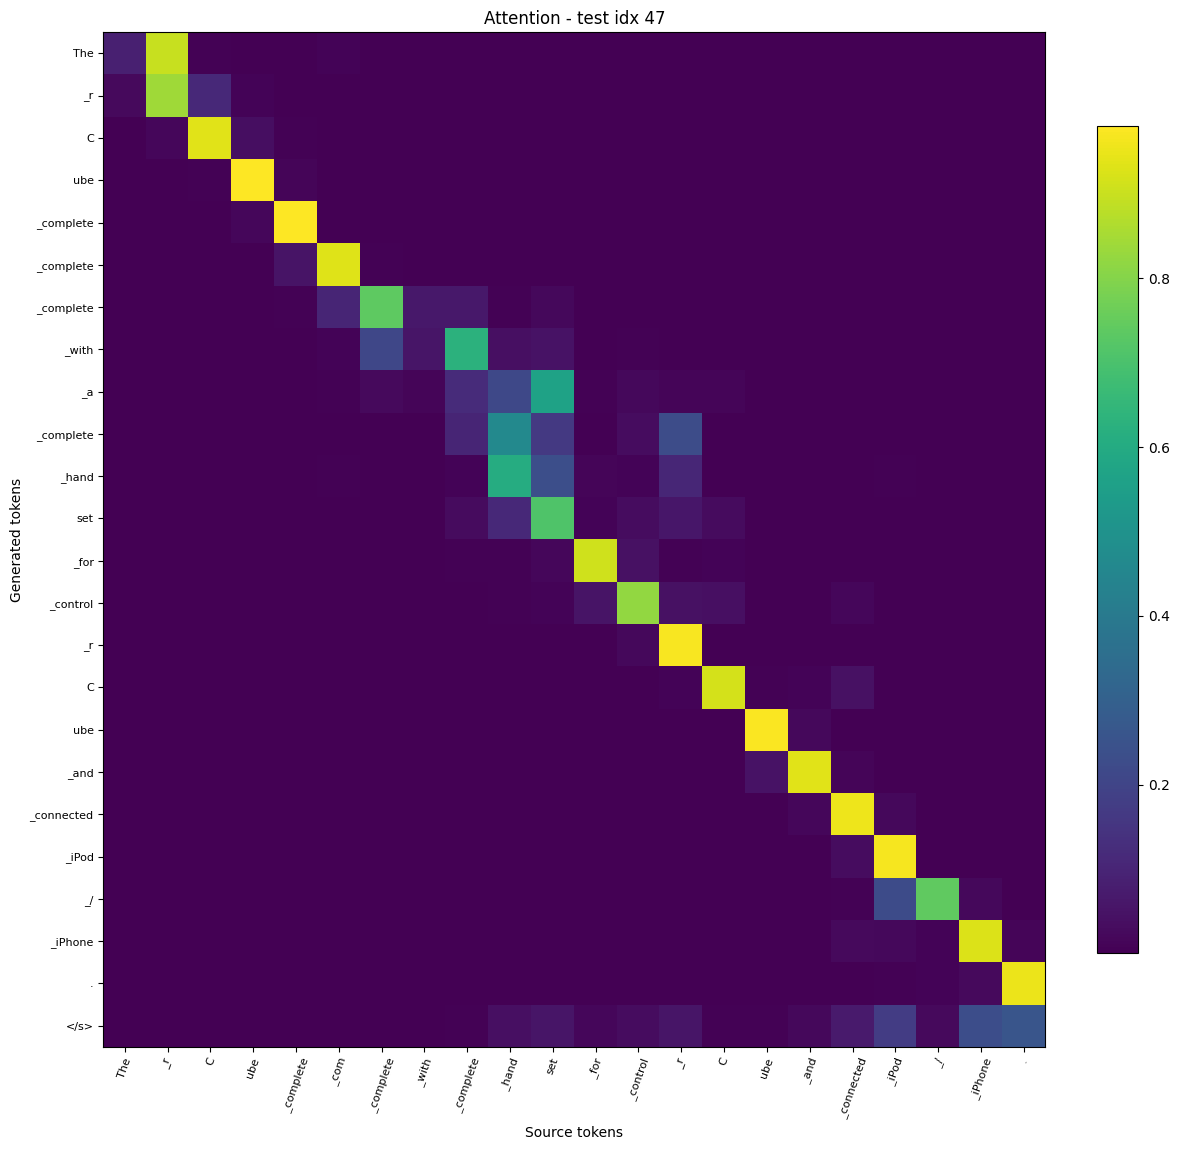

[47] SRC : The rCube complete com complete with complete handset for control rCube and connected iPod / iPhone.
     PRED: The rCube complete complete complete with a complete handset for control rCube and connected iPod / iPhone.
     REF : The rCube comes complete with a remote handset for control the rCube and its connected iPod / iPhone.



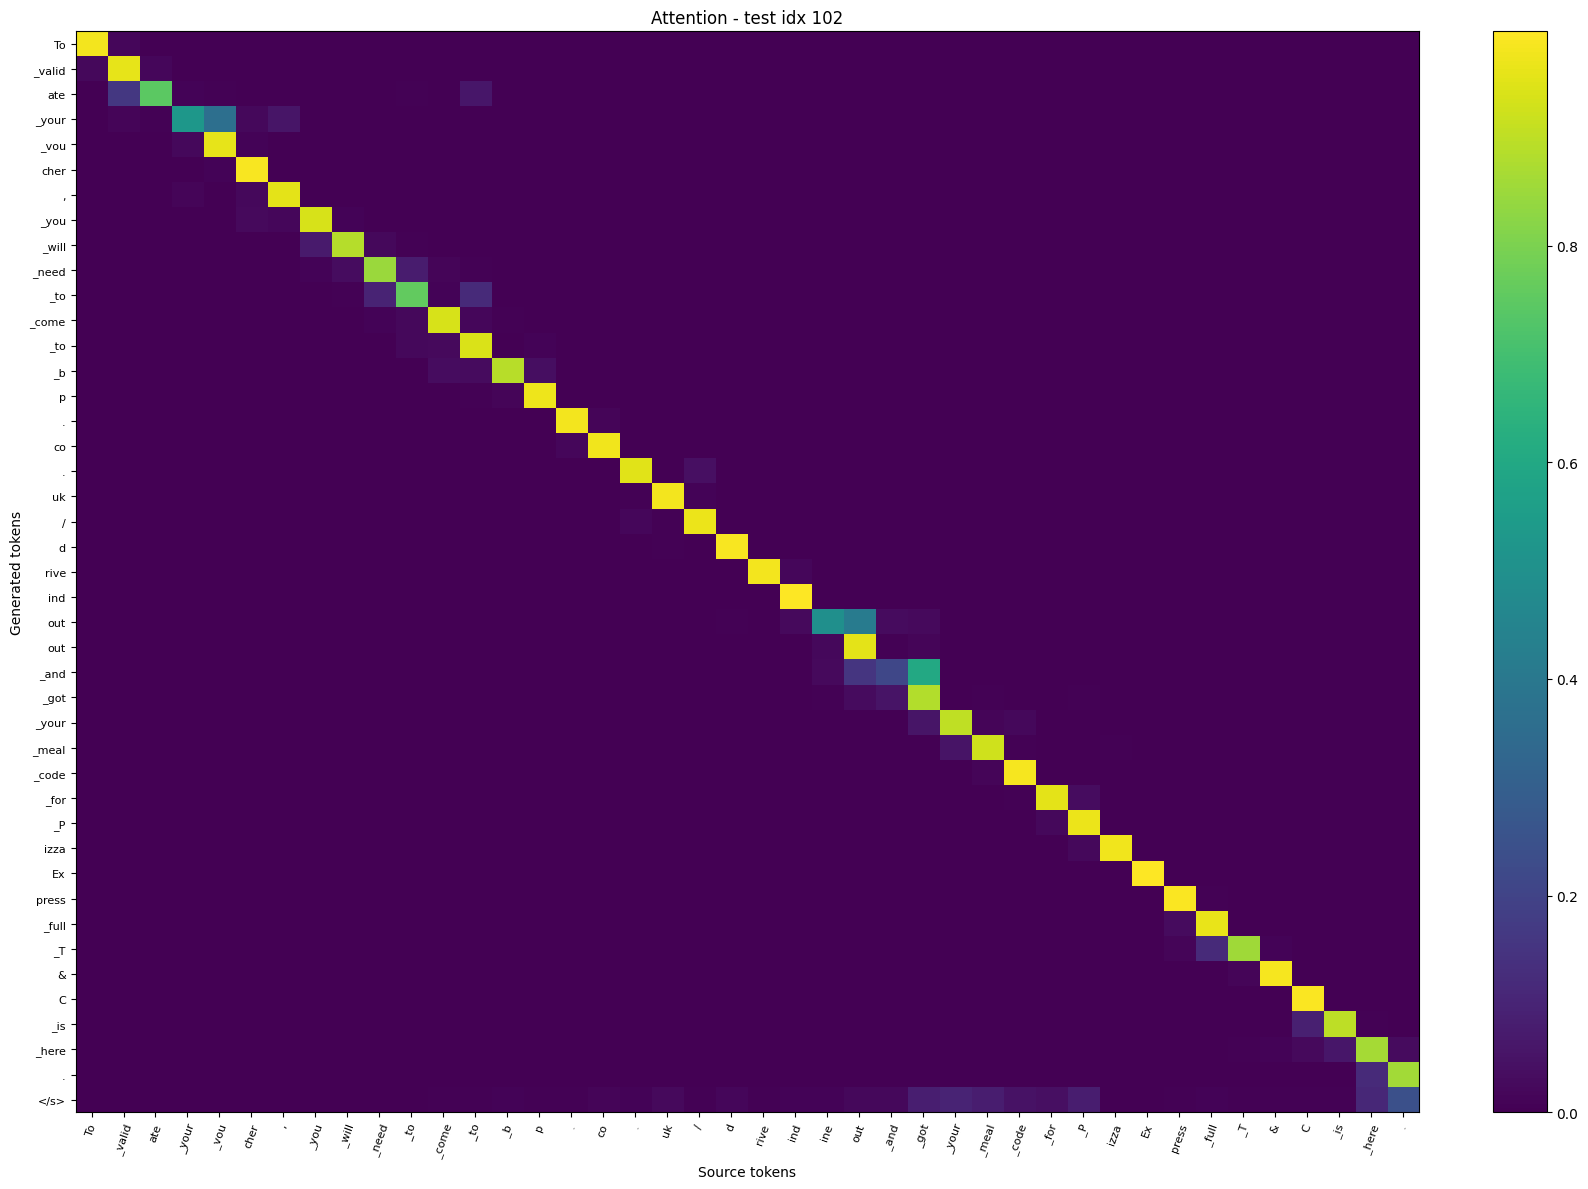

[102] SRC : To validate your voucher, you will need to come to bp.co.uk/driveindineout and got your meal code for PizzaExpress full T&C is here.
     PRED: To validate your voucher, you will need to come to bp.co.uk/driveindoutout and got your meal code for PizzaExpress full T&C is here.
     REF : To validate your vouchers, you will need to visit bp.co.uk/driveindineout and get your meal code for PizzaExpress. Full T&Cs are here as well.



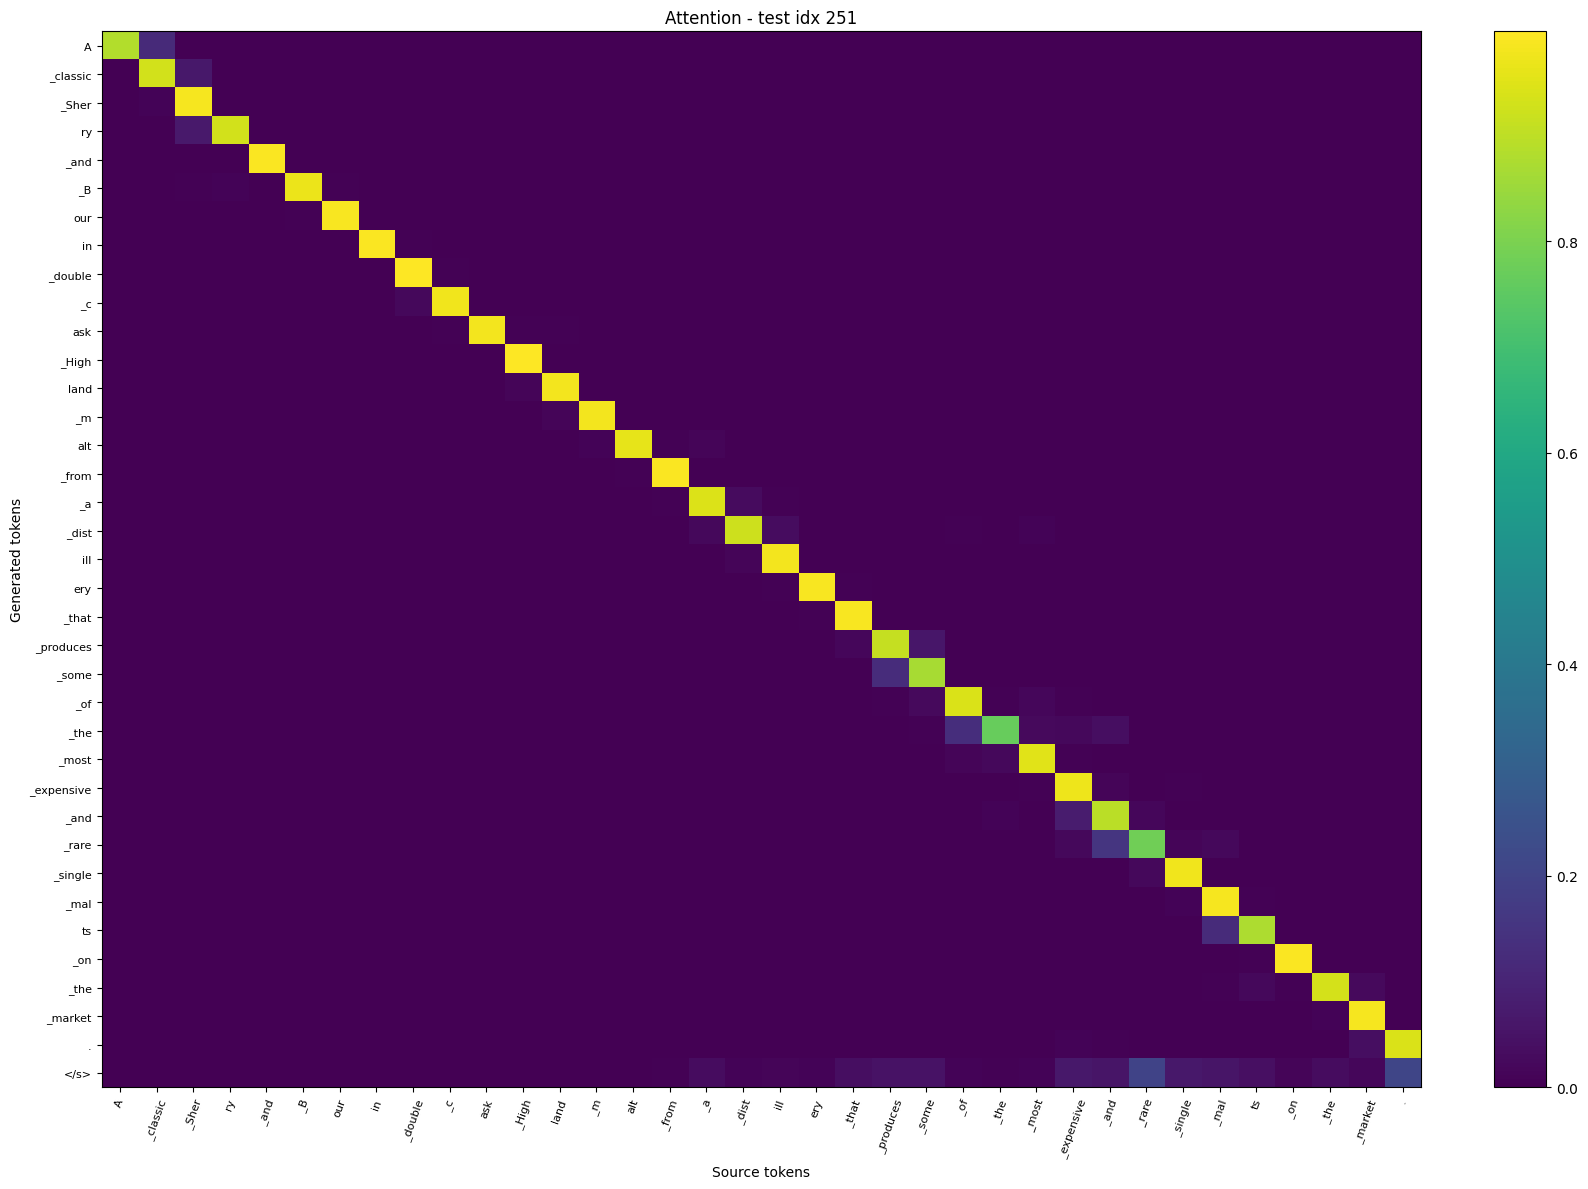

[251] SRC : A classic Sherry and Bourin double cask Highland malt from a distillery that produces some of the most expensive and rare single malts on the market.
     PRED: A classic Sherry and Bourin double cask Highland malt from a distillery that produces some of the most expensive and rare single malts on the market.
     REF : A classic Sherry and Bourbon double cask matured Highland malt from a distillery that produces some of the most expensive and rare single malts on the market.



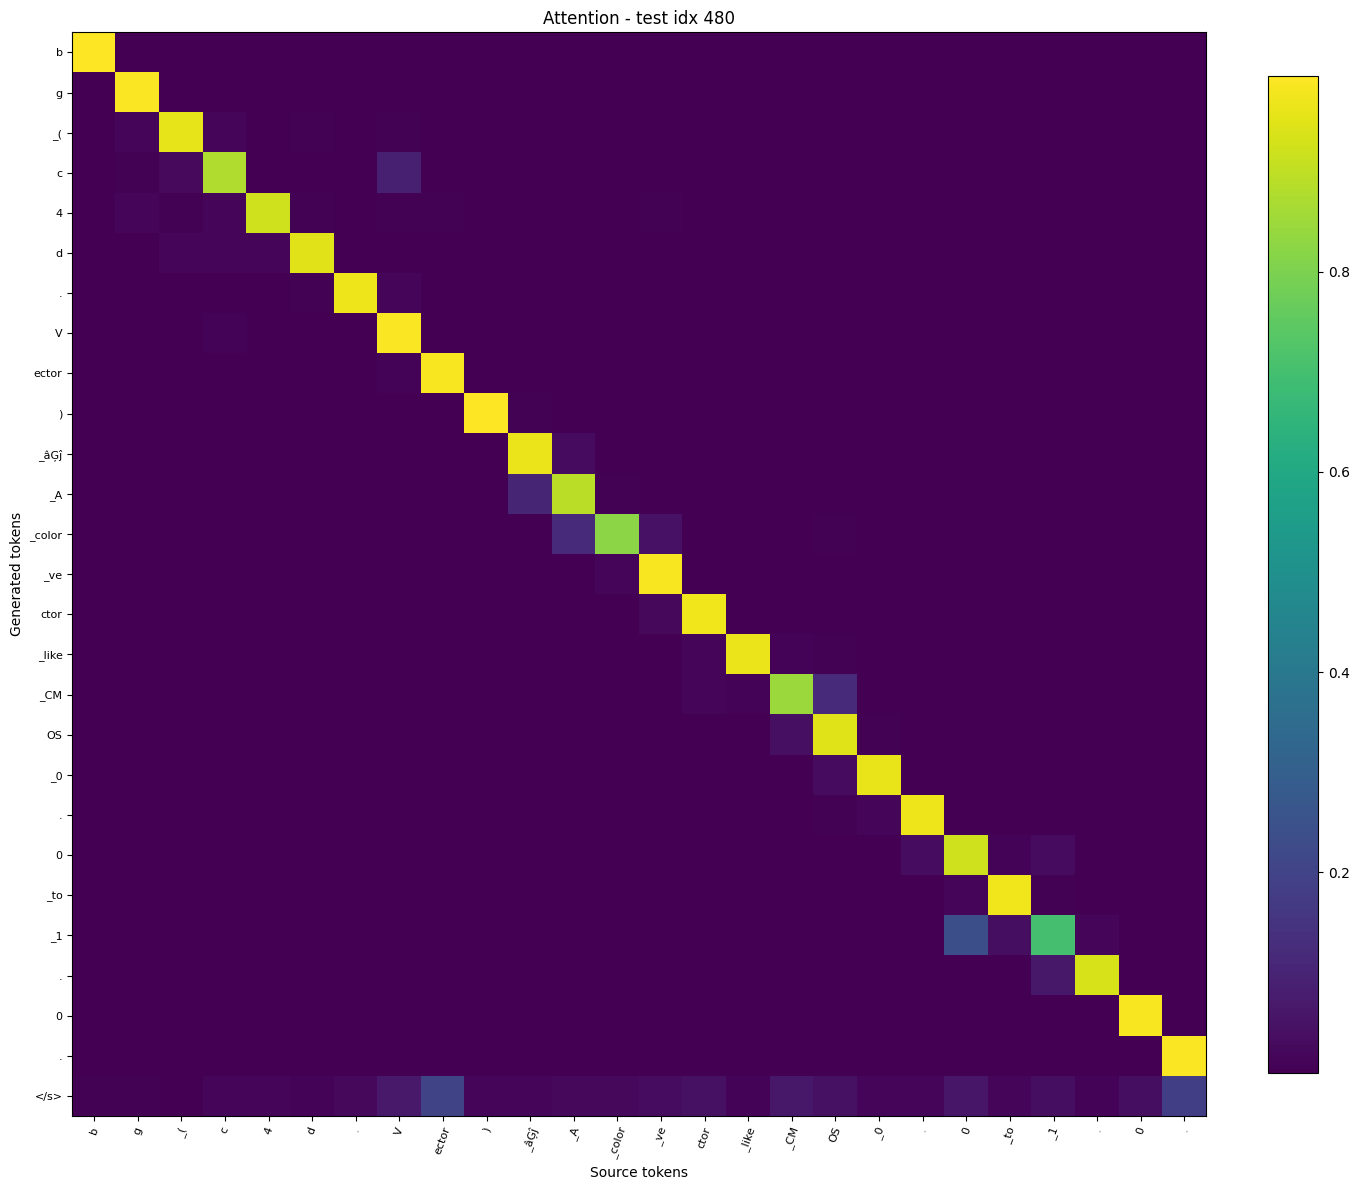

[480] SRC : bg (c4d.Vector) – A color vector like CMOS 0.0 to 1.0.
     PRED: bg (c4d.Vector) – A color vector like CMOS 0.0 to 1.0.
     REF : bg (c4d.Vector) – A color vector from 0.0 to 1.0.



In [17]:
def pretty(tok_id):
    t = tokenizer.id_to_token(int(tok_id))
    return t.replace("\u0120", "_") if t else "?"


PICKS = [3, 47, 102, 251, 480]

for idx in PICKS:
    if idx >= len(test_ds):
        continue
    src, tgt = test_ds[idx]
    src_b = src.unsqueeze(0).to(DEVICE)
    src_lens = torch.tensor([len(src)], device=DEVICE)
    out_ids, attn = model.greedy_decode(src_b, src_lens,
                                        max_len=CFG["max_len"], return_attn=True)
    out_ids = out_ids[0].cpu().tolist()
    attn = attn[0].cpu().numpy()

    if EOS_ID in out_ids:
        cut = out_ids.index(EOS_ID) + 1
        out_ids = out_ids[:cut]; attn = attn[:cut]

    src_labels = [pretty(t) for t in src.tolist()]
    out_labels = [pretty(t) for t in out_ids]

    fig, ax = plt.subplots(figsize=(min(0.45*len(src_labels)+2, 16),
                                    min(0.4*len(out_labels)+2, 12)))
    im = ax.imshow(attn, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(src_labels)))
    ax.set_xticklabels(src_labels, rotation=70, fontsize=8)
    ax.set_yticks(range(len(out_labels)))
    ax.set_yticklabels(out_labels, fontsize=8)
    ax.set_xlabel("Source tokens"); ax.set_ylabel("Generated tokens")
    ax.set_title(f"Attention - test idx {idx}")
    fig.colorbar(im, ax=ax, fraction=0.04)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/attn_{idx}.png", dpi=150)
    plt.show()

    print(f"[{idx}] SRC : {ids_to_text(src.tolist())}")
    print(f"     PRED: {ids_to_text(out_ids)}")
    print(f"     REF : {ids_to_text(tgt.tolist())}\n")

## 12. Qualitative examples - where Phase 4 beats Phase 3

Auto-print test cases where Phase 4 matched the reference but Phase 3 did not. Hand-pick 10 for the report and tie each to a grammar rule.

In [18]:
print("=" * 60)
print("Phase 4 wins (P4 == ref, P3 != ref)")
print("=" * 60)
shown = 0
for s, p3, p4, r in zip(srcs_text, ph3_preds, preds_greedy, refs_text):
    if p4.strip() == r.strip() and p3.strip() != r.strip():
        print(f"SRC : {s}")
        print(f"P3  : {p3}")
        print(f"P4  : {p4}")
        print(f"REF : {r}\n")
        shown += 1
        if shown >= 10:
            break
if shown == 0:
    print("No exact-match wins - compare GLEU per sentence instead.")

Phase 4 wins (P4 == ref, P3 != ref)
SRC : 25% off Generation Brands Lighting and-Home Decor.
P3  : 25% off Generation Brands and Home- Decorating.
P4  : 25% off Generation Brands Lighting and Home Decor.
REF : 25% off Generation Brands Lighting and Home Decor.

SRC : Whipped sweet potato with a melted marshmallow topping
P3  : Whipped sweet potatoes with a melted marshm to melted.
P4  : Whipped sweet potato with a melted marshmallow topping.
REF : Whipped sweet potato with a melted marshmallow topping.

SRC : rotary club certificate template of acceptance sample. or blank templates templa.
P3  : Arty cinema certificate template for sample or verding palm template.
P4  : rotary club certificate template of acceptance sample or blank templates templa.
REF : rotary club certificate template of acceptance sample or blank templates templa.

SRC : 'Marc 'is a Horn-FX artist.
P3  : Marcis a "FiveX' artist.
P4  : Marc is a Horn-FX artist.
REF : Marc is a Horn-FX artist.

SRC : If your joint is

## 13. Save run summary

Headline numbers + deltas vs Phase 3 to `summary.json`. Phase 5 loads this for the master comparison table.

In [19]:
summary = {
    "model": "lstm_seq2seq_bahdanau",
    "params_M": round(n_params/1e6, 2),
    "config": CFG,
    "best_val_gleu": best_gleu,
    "test": {
        "greedy": {
            "exact_match": exact_match(preds_greedy, refs_text),
            "gleu": corpus_gleu([[r.split()] for r in refs_text],
                                [p.split() for p in preds_greedy]),
        },
        "beam4": {
            "exact_match": exact_match(preds_beam, refs_text),
            "gleu": corpus_gleu([[r.split()] for r in refs_text],
                                [p.split() for p in preds_beam]),
        },
    },
    "compare_to_phase3": {
        "EM_delta": exact_match(preds_greedy, refs_text)
                    - ph3["test"]["greedy"]["exact_match"],
        "GLEU_delta": corpus_gleu([[r.split()] for r in refs_text],
                                  [p.split() for p in preds_greedy])
                      - ph3["test"]["greedy"]["gleu"],
    },
}
with open(f"{OUT_DIR}/summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

print("\nFiles in OUT_DIR:")
for f in sorted(os.listdir(OUT_DIR)):
    print("  ", f, f"({os.path.getsize(os.path.join(OUT_DIR, f))/1e6:.1f} MB)")

{
  "model": "lstm_seq2seq_bahdanau",
  "params_M": 29.06,
  "config": {
    "vocab_size": 16000,
    "emb_dim": 256,
    "enc_hidden": 256,
    "dec_hidden": 512,
    "attn_dim": 256,
    "max_len": 64,
    "batch_size": 64,
    "lr": 0.001,
    "weight_decay": 1e-05,
    "clip": 1.0,
    "epochs": 3,
    "tf_start": 1.0,
    "tf_end": 0.5,
    "log_every": 200,
    "ckpt_every": 2000,
    "max_train": 850000,
    "max_val": 50000,
    "max_test": 100000,
    "max_val_eval": 5000,
    "use_attention": true
  },
  "best_val_gleu": 0.5921598278872536,
  "test": {
    "greedy": {
      "exact_match": 0.02388235294117647,
      "gleu": 0.5992940904044674
    },
    "beam4": {
      "exact_match": 0.02644705882352941,
      "gleu": 0.6183894127634785
    }
  },
  "compare_to_phase3": {
    "EM_delta": 0.01584705882352941,
    "GLEU_delta": 0.386492440585441
  }
}

Files in OUT_DIR:
   attn_102.png (0.1 MB)
   attn_251.png (0.1 MB)
   attn_3.png (0.0 MB)
   attn_47.png (0.1 MB)
   attn_480.